In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
# Load the taxis dataset
df = sns.load_dataset("taxis")

# Display the first 5 rows
df.head()

,pickup,dropoff,passengers,distance,fare,tip,tolls,total,color,payment,pickup_zone,dropoff_zone,pickup_borough,dropoff_borough
0,2019-03-23 20:21:09,2019-03-23 20:27:24,1,1.60,7.0,2.15,0.0,12.95,yellow,credit card,Lenox Hill West,UN/Turtle Bay South,Manhattan,Manhattan
1,2019-03-04 16:11:55,2019-03-04 16:19:00,1,0.79,5.0,0.00,0.0,9.30,yellow,cash,Upper West Side South,Upper West Side South,Manhattan,Manhattan
2,2019-03-27 17:53:01,2019-03-27 18:00:25,1,1.37,7.5,2.36,0.0,14.16,yellow,credit card,Alphabet City,West Village,Manhattan,Manhattan
3,2019-03-10 01:23:59,2019-03-10 01:49:51,1,7.70,27.0,6.15,0.0,36.95,yellow,credit card,Hudson Sq,Yorkville West,Manhattan,Manhattan
4,2019-03-30 13:27:42,2019-03-30 13:37:14,3,2.16,9.0,1.10,0.0,13.40,yellow,credit card,Midtown East,Yorkville West,Manhattan,Manhattan


In [3]:
# Check the number of rows and columns
print("Number of rows and columns:", df.shape)

# Display column names
print("\nColumn names:")
print(df.columns.tolist())

Number of rows and columns: (6433, 14)

Column names:
['pickup', 'dropoff', 'passengers', 'distance', 'fare', 'tip', 'tolls', 'total', 'color', 'payment', 'pickup_zone', 'dropoff_zone', 'pickup_borough', 'dropoff_borough']


In [4]:
# Check the data type of every column
print(df.dtypes)

pickup             datetime64[ns]
dropoff            datetime64[ns]
passengers                  int64
distance                  float64
fare                      float64
tip                       float64
tolls                     float64
total                     float64
color                      object
payment                    object
pickup_zone                object
dropoff_zone               object
pickup_borough             object
dropoff_borough            object
dtype: object


In [5]:
# Check for missing values in each column
print(df.isnull().sum())

pickup              0
dropoff             0
passengers          0
distance            0
fare                0
tip                 0
tolls               0
total               0
color               0
payment            44
pickup_zone        26
dropoff_zone       45
pickup_borough     26
dropoff_borough    45
dtype: int64


In [6]:
# Calculate the percentage of missing values
missing_percentage = (df.isnull().sum() / len(df)) * 100

print(missing_percentage)

pickup             0.000000
dropoff            0.000000
passengers         0.000000
distance           0.000000
fare               0.000000
tip                0.000000
tolls              0.000000
total              0.000000
color              0.000000
payment            0.683973
pickup_zone        0.404166
dropoff_zone       0.699518
pickup_borough     0.404166
dropoff_borough    0.699518
dtype: float64


In [7]:
# Find numerical columns
numerical_columns = df.select_dtypes(include="number").columns

# Fill missing numerical values with the median
for column in numerical_columns:
    df[column] = df[column].fillna(df[column].median())

print("Missing numerical values have been filled.")

Missing numerical values have been filled.


In [8]:
# Find categorical columns
categorical_columns = df.select_dtypes(include="object").columns

# Fill missing categorical values with the mode
for column in categorical_columns:
    df[column] = df[column].fillna(df[column].mode()[0])

print("Missing categorical values have been filled.")

Missing categorical values have been filled.


In [9]:
# Check missing values after cleaning
print(df.isnull().sum())

pickup             0
dropoff            0
passengers         0
distance           0
fare               0
tip                0
tolls              0
total              0
color              0
payment            0
pickup_zone        0
dropoff_zone       0
pickup_borough     0
dropoff_borough    0
dtype: int64


In [10]:
# Convert pickup column to datetime format
df["pickup"] = pd.to_datetime(df["pickup"])

# Check the data type
print(df["pickup"].dtype)

datetime64[ns]


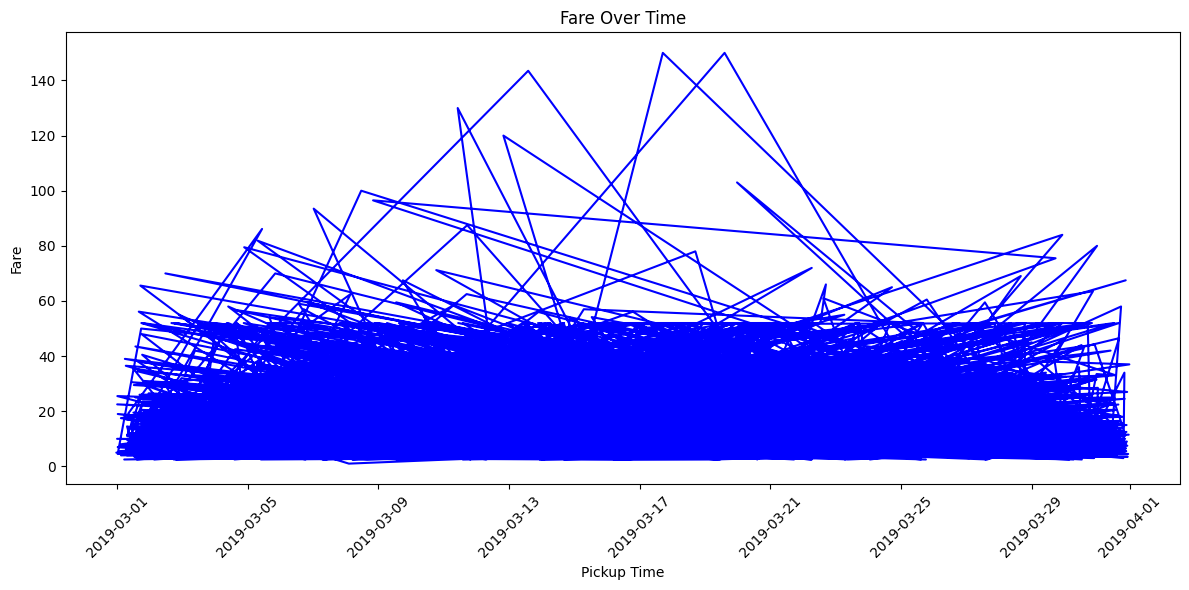

In [11]:
# Line chart of fare over time

plt.figure(figsize=(12, 6))

plt.plot(df["pickup"], df["fare"], color="blue")

plt.title("Fare Over Time")
plt.xlabel("Pickup Time")
plt.ylabel("Fare")

plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

In [12]:
# Calculate total fare for each pickup borough
total_fare = df.groupby("pickup_borough")["fare"].sum()

print(total_fare)

pickup_borough
Bronx         2078.91
Brooklyn      6327.48
Manhattan    59426.42
Queens       16382.06
Name: fare, dtype: float64


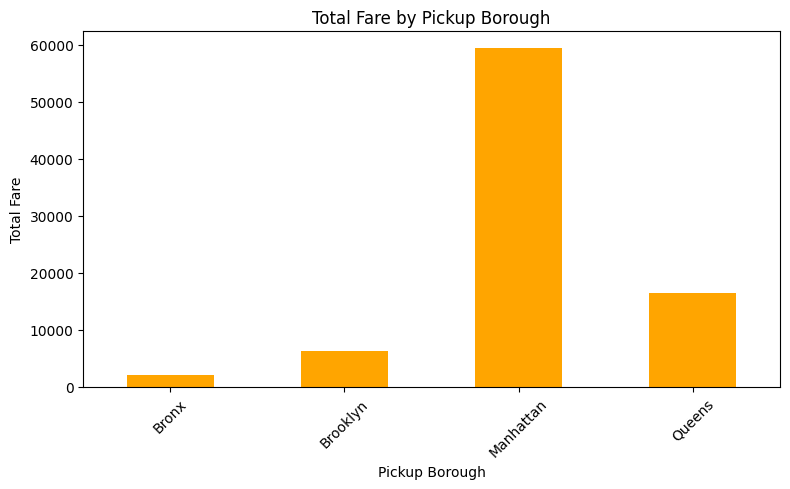

In [13]:
# Create bar chart

plt.figure(figsize=(8, 5))

total_fare.plot(kind="bar", color="orange")

plt.title("Total Fare by Pickup Borough")
plt.xlabel("Pickup Borough")
plt.ylabel("Total Fare")

plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

In [14]:
# Count trips for each payment method
payment_counts = df["payment"].value_counts()

print(payment_counts)

payment
credit card    4621
cash           1812
Name: count, dtype: int64


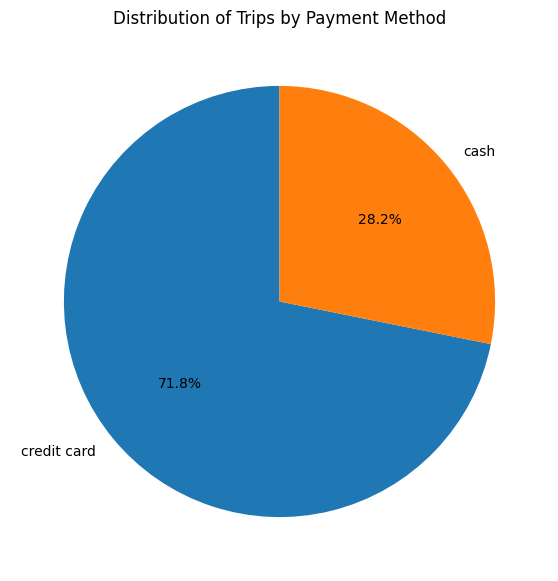

In [15]:
# Create pie chart

plt.figure(figsize=(7, 7))

plt.pie(
    payment_counts,
    labels=payment_counts.index,
    autopct="%1.1f%%",
    startangle=90
)

plt.title("Distribution of Trips by Payment Method")

plt.show()

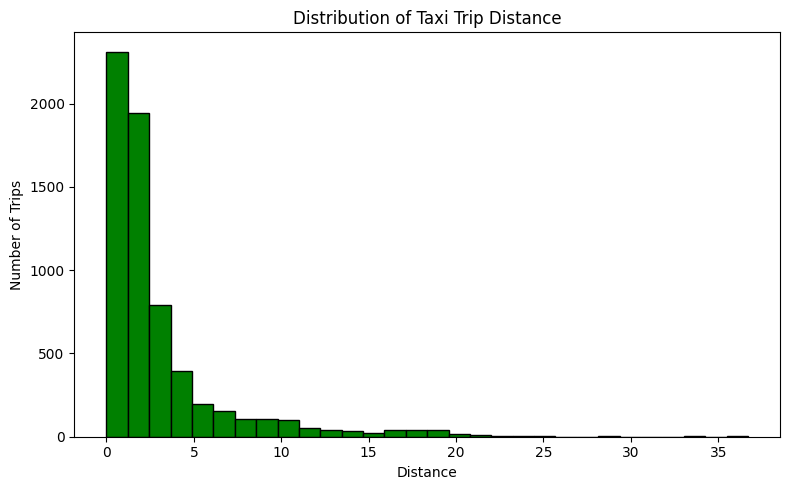

In [16]:
# Create histogram of distance

plt.figure(figsize=(8, 5))

plt.hist(
    df["distance"],
    bins=30,
    color="green",
    edgecolor="black"
)

plt.title("Distribution of Taxi Trip Distance")
plt.xlabel("Distance")
plt.ylabel("Number of Trips")

plt.tight_layout()
plt.show()

<Figure size 1000x600 with 0 Axes>

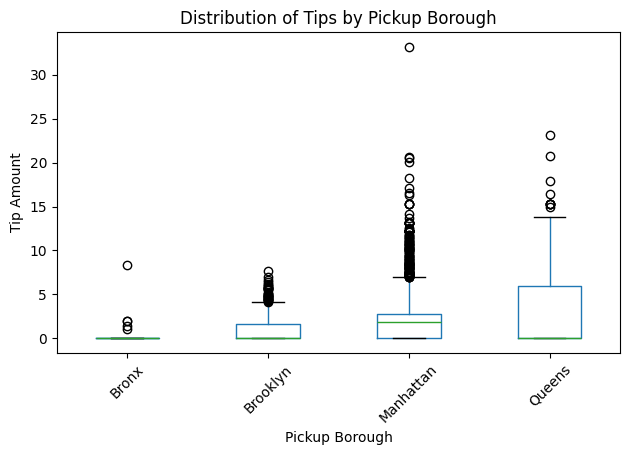

In [17]:
# Create box plot of tips by pickup borough

plt.figure(figsize=(10, 6))

df.boxplot(
    column="tip",
    by="pickup_borough",
    grid=False
)

plt.title("Distribution of Tips by Pickup Borough")
plt.suptitle("")
plt.xlabel("Pickup Borough")
plt.ylabel("Tip Amount")

plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

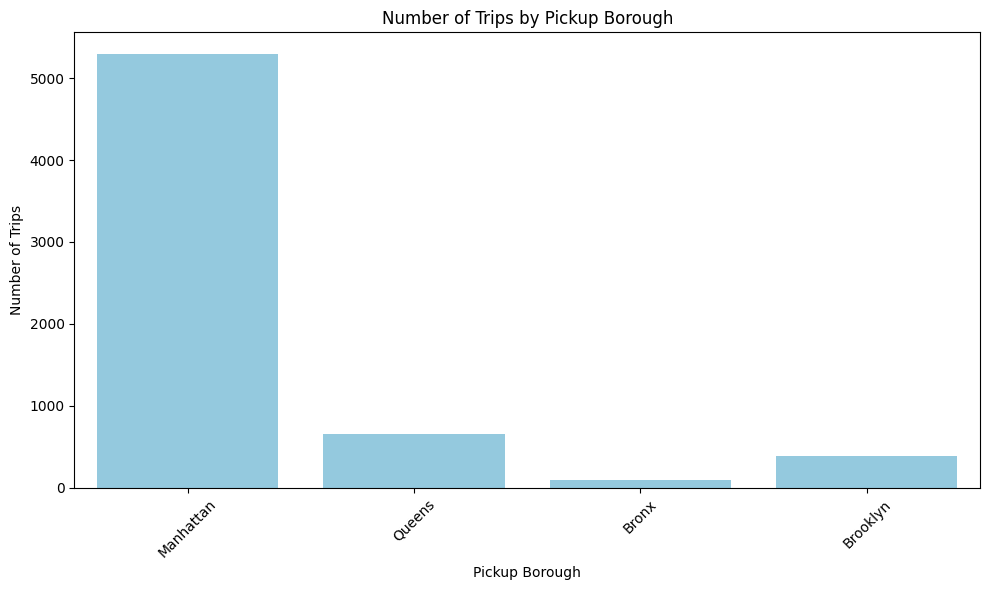

In [18]:
# Count plot of trips by pickup borough

plt.figure(figsize=(10, 6))

sns.countplot(
    data=df,
    x="pickup_borough",
    color="skyblue"
)

plt.title("Number of Trips by Pickup Borough")
plt.xlabel("Pickup Borough")
plt.ylabel("Number of Trips")

plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

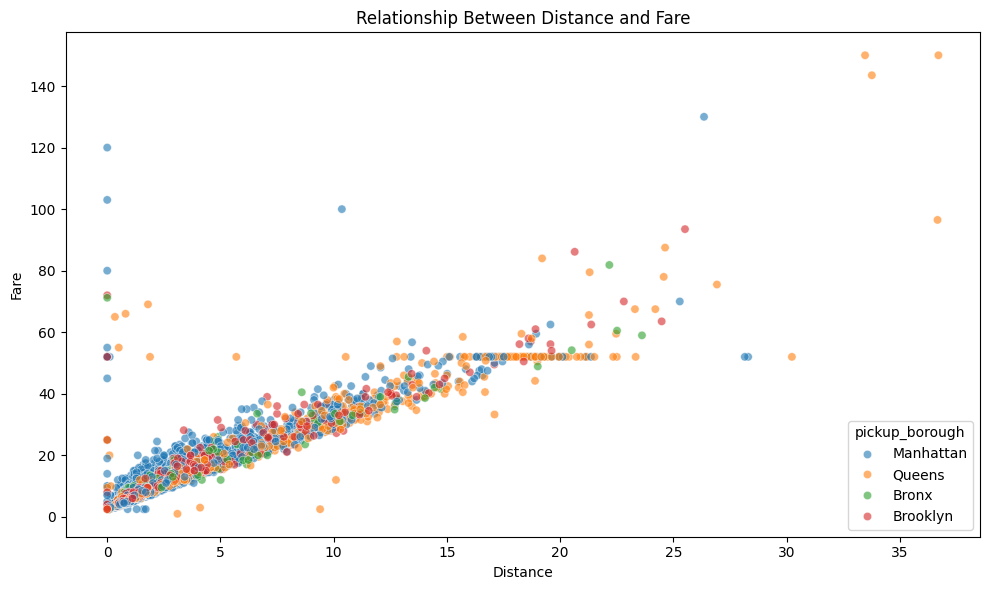

In [19]:
# Scatter plot of distance and fare

plt.figure(figsize=(10, 6))

sns.scatterplot(
    data=df,
    x="distance",
    y="fare",
    hue="pickup_borough",
    alpha=0.6
)

plt.title("Relationship Between Distance and Fare")
plt.xlabel("Distance")
plt.ylabel("Fare")

plt.tight_layout()
plt.show()

In [20]:
# Select numerical columns
numeric_columns = [
    "distance",
    "fare",
    "tip",
    "tolls",
    "total"
]

# Calculate correlation matrix
correlation = df[numeric_columns].corr()

print(correlation)

          distance      fare       tip     tolls     total
distance  1.000000  0.920108  0.452589  0.635267  0.904676
fare      0.920108  1.000000  0.488612  0.609307  0.974358
tip       0.452589  0.488612  1.000000  0.413619  0.646186
tolls     0.635267  0.609307  0.413619  1.000000  0.683142
total     0.904676  0.974358  0.646186  0.683142  1.000000


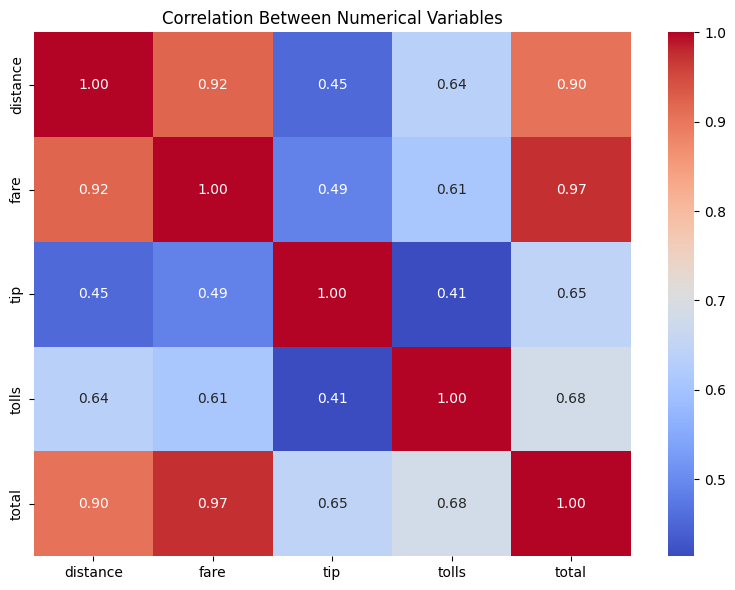

In [21]:
# Create heatmap

plt.figure(figsize=(8, 6))

sns.heatmap(
    correlation,
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Between Numerical Variables")

plt.tight_layout()
plt.show()

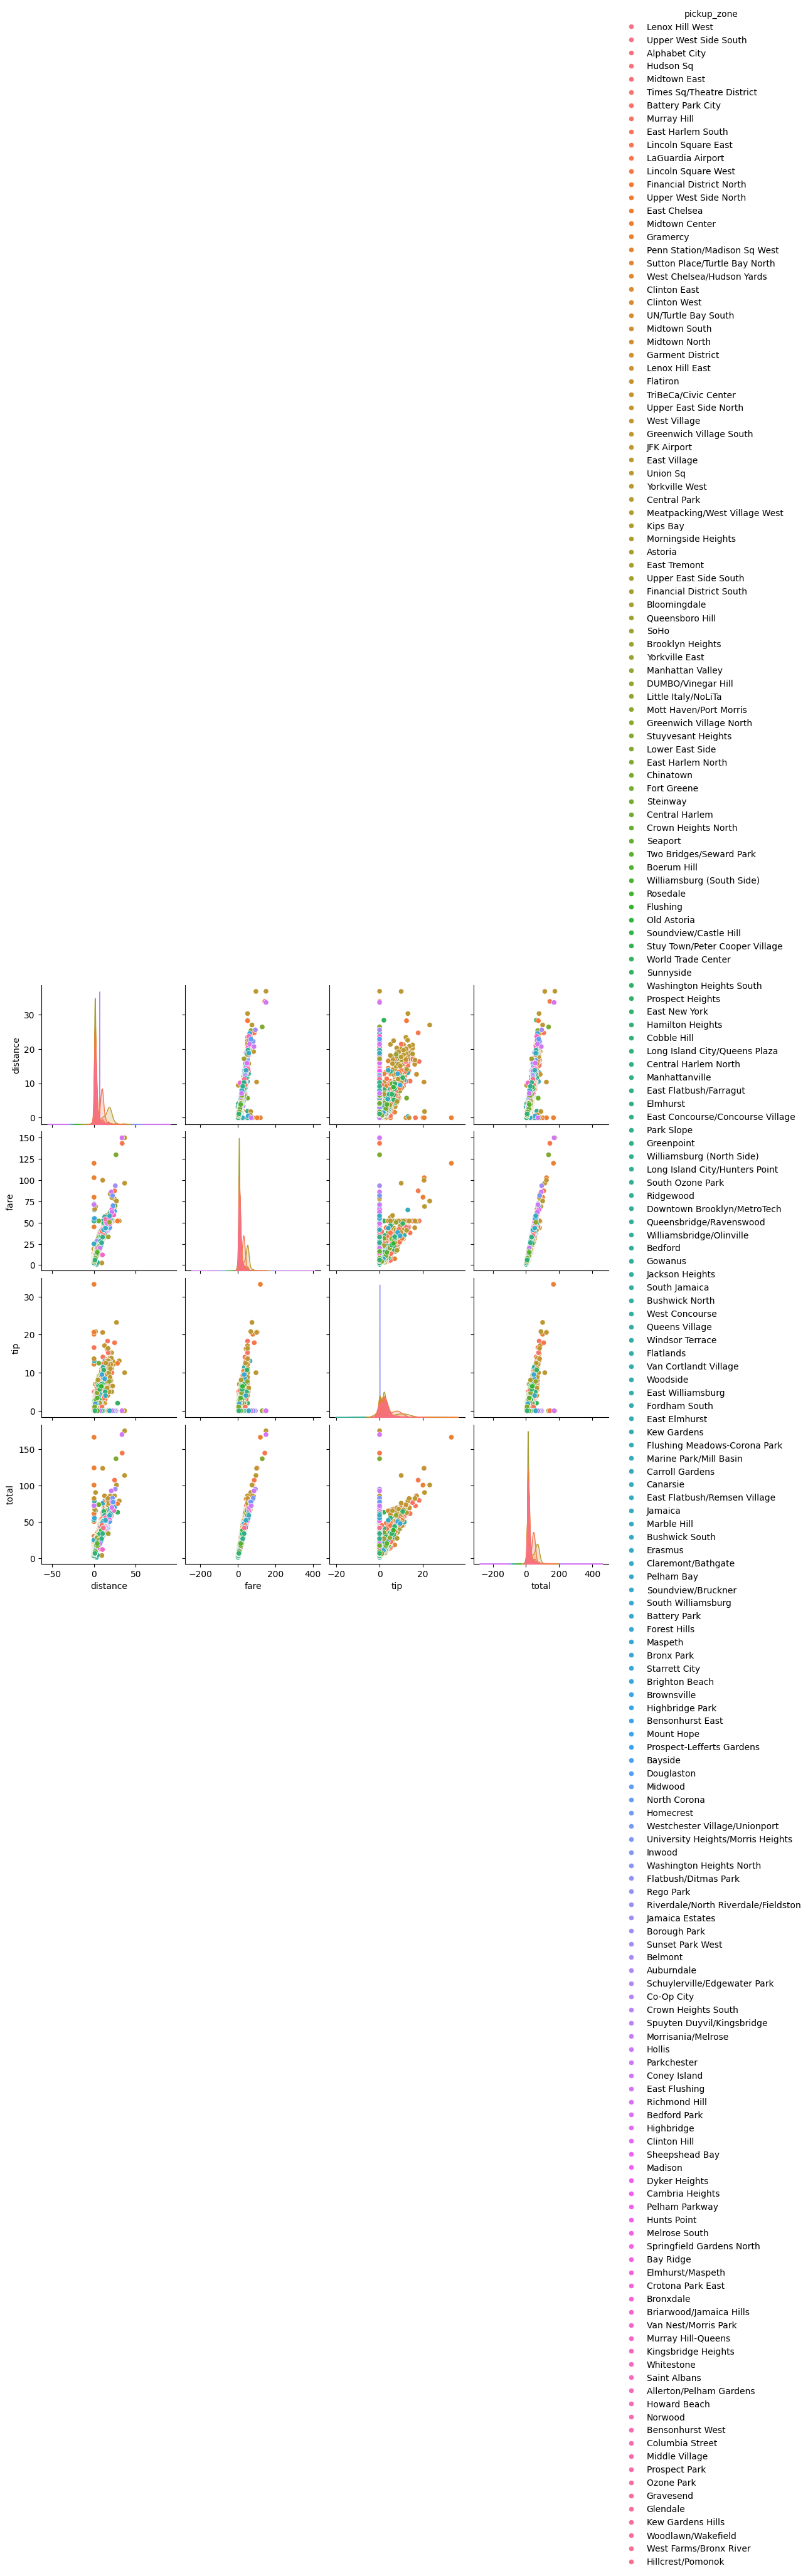

In [22]:
# Select columns for pair plot

pair_columns = [
    "distance",
    "fare",
    "tip",
    "total",
    "pickup_zone"
]

# Create pair plot

sns.pairplot(
    df[pair_columns],
    hue="pickup_zone"
)

plt.show()

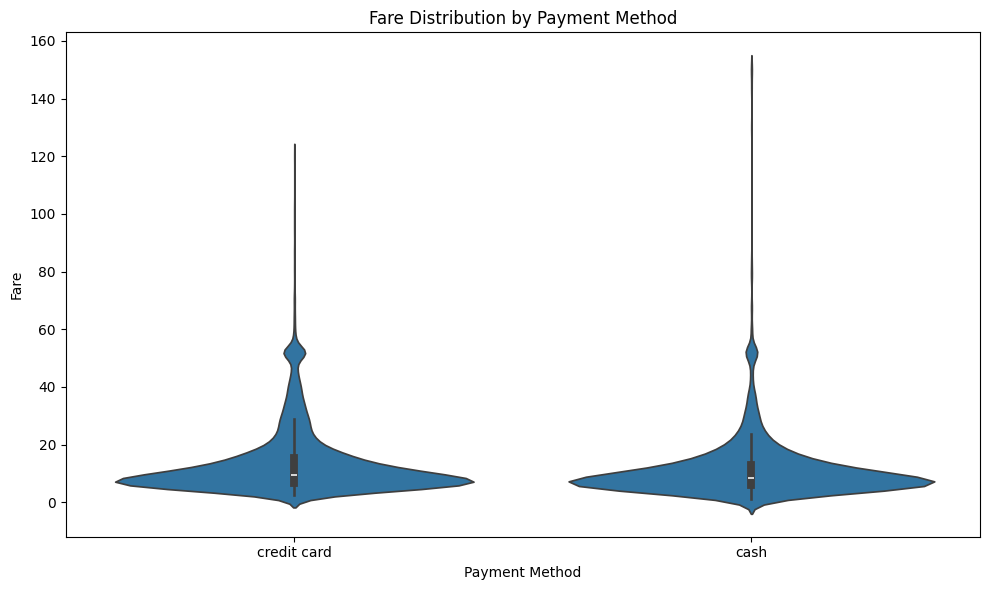

In [23]:
# Create violin plot

plt.figure(figsize=(10, 6))

sns.violinplot(
    data=df,
    x="payment",
    y="fare"
)

plt.title("Fare Distribution by Payment Method")
plt.xlabel("Payment Method")
plt.ylabel("Fare")

plt.tight_layout()
plt.show()

In [24]:
# Save the cleaned dataset as a CSV file

df.to_csv("cleaned_taxis.csv", index=False)

print("Cleaned dataset saved successfully!")

Cleaned dataset saved successfully!


In [25]:
# Display final dataset information

print("Final dataset shape:", df.shape)

print("\nMissing values:")
print(df.isnull().sum())

print("\nFirst 5 rows:")
display(df.head())

Final dataset shape: (6433, 14)

Missing values:
pickup             0
dropoff            0
passengers         0
distance           0
fare               0
tip                0
tolls              0
total              0
color              0
payment            0
pickup_zone        0
dropoff_zone       0
pickup_borough     0
dropoff_borough    0
dtype: int64

First 5 rows:


,pickup,dropoff,passengers,distance,fare,tip,tolls,total,color,payment,pickup_zone,dropoff_zone,pickup_borough,dropoff_borough
0,2019-03-23 20:21:09,2019-03-23 20:27:24,1,1.60,7.0,2.15,0.0,12.95,yellow,credit card,Lenox Hill West,UN/Turtle Bay South,Manhattan,Manhattan
1,2019-03-04 16:11:55,2019-03-04 16:19:00,1,0.79,5.0,0.00,0.0,9.30,yellow,cash,Upper West Side South,Upper West Side South,Manhattan,Manhattan
2,2019-03-27 17:53:01,2019-03-27 18:00:25,1,1.37,7.5,2.36,0.0,14.16,yellow,credit card,Alphabet City,West Village,Manhattan,Manhattan
3,2019-03-10 01:23:59,2019-03-10 01:49:51,1,7.70,27.0,6.15,0.0,36.95,yellow,credit card,Hudson Sq,Yorkville West,Manhattan,Manhattan
4,2019-03-30 13:27:42,2019-03-30 13:37:14,3,2.16,9.0,1.10,0.0,13.40,yellow,credit card,Midtown East,Yorkville West,Manhattan,Manhattan
